# EDA

## Univariate EDA 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv('/Users/javohireshonov/Desktop/Study/Projects/Uzbekistan car postings /data/Prepared/car_data_clean.csv')

In [3]:
df.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,year_valid
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,NaN,...,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20,True
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00,True
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,NaN,...,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10,True
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,NaN,...,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05,True
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,626,626,Other,1250.0,NaN,NaN,NaN,16,1.60,True


In [4]:
df.columns

Index(['url', 'region', 'district', 'price_raw', 'currency', 'description',
       'image_url', 'model_raw', 'body_type', 'sale_type', 'year', 'mileage',
       'transmission', 'color', 'engine_volume', 'fuel_type', 'condition',
       'owners_count', 'additional_options', 'model_clean', 'car_name',
       'brand', 'price_usd', 'mileage_raw', 'mileage_log', 'mileage_group',
       'engine_volume_raw', 'engine_volume_l', 'year_valid'],
      dtype='object')

In [5]:
df.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,year_valid
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,NaN,...,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20,True
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00,True
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,NaN,...,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10,True
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,NaN,...,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05,True
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,626,626,Other,1250.0,NaN,NaN,NaN,16,1.60,True


## Price

In [6]:
df['price_usd'].describe()

count     46101.000000
mean      10047.019121
std       11533.889485
min         500.000000
25%        3916.700000
50%        7000.000000
75%       13200.000000
max      167414.400000
Name: price_usd, dtype: float64

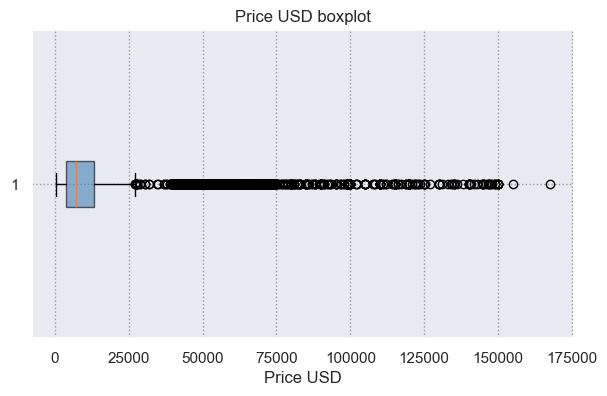

In [7]:
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
price = df.loc[df['price_usd'].notna(), 'price_usd']
fig, axes = plt.subplots(figsize=(7, 4))
ax1 = axes
ax1.boxplot(price, vert=False,patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
ax1.set_title('Price USD boxplot')
ax1.set_xlabel("Price USD")


plt.show()

What I see  
- Most cars priced between as low as 4000k to 10000k
- The price disturebution heavily right-skewed due to high listed cars
- Median price is roughly ~10k–12k USD
- Majority of cars are cheap, small portion are very expensive

What it might mean (interpretation)
- Mass market dominance:
  - Most cars are affortable
- Luxury cars are exist but It takes small proportion
  - High price outliers = Premium cars(Mercedes, BMW...)
- Outliers are not errors:
- Average price is misleading

What I would do next
- Log transform (CRITICAL for price)
- Combine with mileage

The car market is heavily right-skewed, with most vehicles priced below $20,000. A small number of high-value listings significantly extend the upper range, indicating the presence of a niche premium segment. Median price provides a more accurate representation than the mean due to extreme outliers.

## Year — bar chart of listing counts

In [8]:
df['year'].describe()

count    46106.000000
mean      2011.080922
std         12.759447
min       1900.000000
25%       2006.000000
50%       2014.000000
75%       2022.000000
max       2025.000000
Name: year, dtype: float64

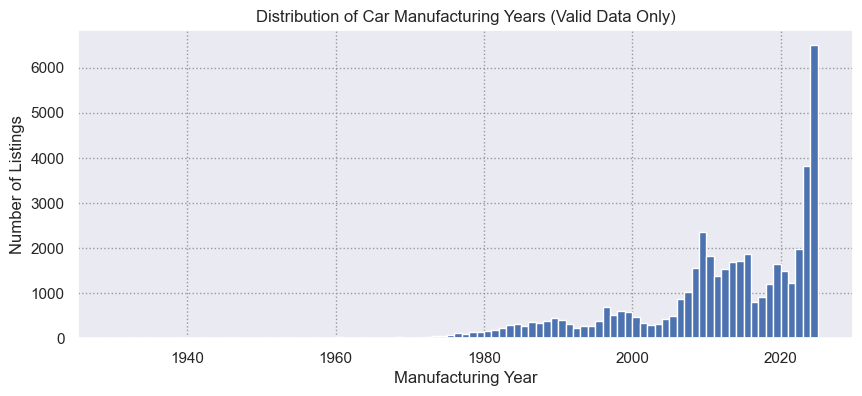

In [9]:
plt.figure(figsize=(10, 4))
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

data = df[df['year_valid']]['year']
bins = np.arange(data.min(), data.max() + 1, 1)

plt.hist(df[df['year_valid']]['year'], bins=bins)

plt.title("Distribution of Car Manufacturing Years (Valid Data Only)")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Listings")

plt.show()

What I see  
- Most cars are between 2005 and 2025
- There is a strong peak between 2021 - 2025
- Very few cars before 1990
- There is a small bump between 2007 -  2010
- Counts increased gradually over time, in 2015 it sharply jumped.
  
What it might mean (interpretation)
- In Uzbekistan, people mostly buy/sell newer cars
- Increased imports or high production by GM
- Old cars are rare:
  - People may not posting it (bias)
- Covid may be the reason
  - More online listings
  - Growth in resale
- Most people sell their car in local places (bias)
- People update often
  
What I would do next
- Create car age column or feature
- Which cars selled newer by using groupby
- Check price vs year
  
The Uzbek car resale market is dominated by relatively new vehicles (post-2010), with a sharp increase after 2015, indicating growing purchasing power, import activity, and digital marketplace usage.

## Mileage

In [10]:
df['mileage'].describe()

count     35346.000000
mean     126926.272591
std      125928.582811
min           0.000000
25%       11111.000000
50%       93000.000000
75%      206000.000000
max      500000.000000
Name: mileage, dtype: float64

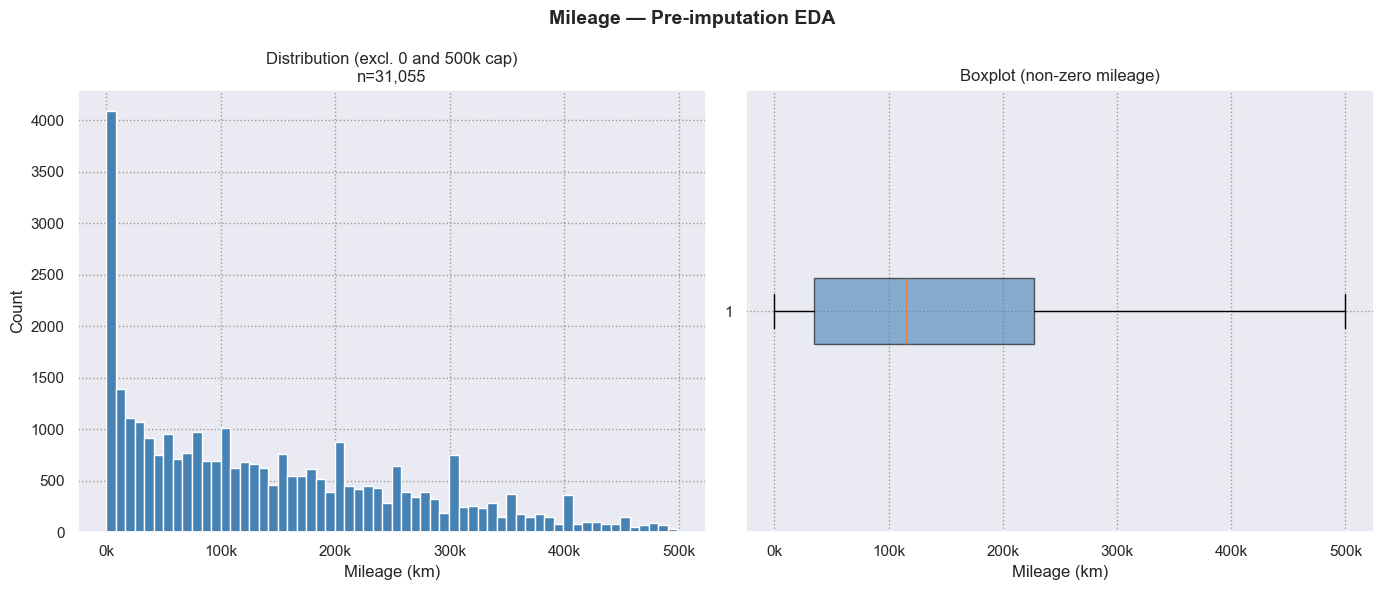

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
axes = np.atleast_2d(axes)
fig.suptitle("Mileage — Pre-imputation EDA", fontsize=14, fontweight="bold")

mileage_valid = df[df["mileage"] > 0]["mileage"].dropna()
mileage_capped = df[df["mileage"] == 500_000]["mileage"]

ax1 = axes[0, 0]
plot_data = df[(df["mileage"] > 0) & (df["mileage"] < 500_000)]["mileage"]
ax1.hist(plot_data, bins=60, color="steelblue", edgecolor="white")
ax1.set_title(f"Distribution (excl. 0 and 500k cap)\nn={len(plot_data):,}")
ax1.set_xlabel("Mileage (km)")
ax1.set_ylabel("Count")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))


# 2. Boxplot — highlights outlier bands
ax2 = axes[0, 1]
ax2.boxplot(mileage_valid, vert=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6))
ax2.set_title("Boxplot (non-zero mileage)")
ax2.set_xlabel("Mileage (km)")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
plt.show()

What I see  
- Most sellers using OLX to sell new cars with mileage 0
- Most cars roughly between 0k - 200k 
- Median is between 110k - 130k
- Some extreme cars (300k - 500k) 

What it might mean (interpretation)
- Low mileage:
  - Could be newer cars
  - Or suspicious values(Sellers puting 0 to hide real value)
- Main market cluster between 50k - 200k
- New and also heavy used cars are being in use
  
What I would do next
- Clean suspicious mileage even more
- price vs mileage

  
> The mileage distribution is heavily right-skewed, with most vehicles concentrated below 200,000 km. A noticeable spike at very low mileage suggests the presence of nearly new cars or potential reporting inconsistencies. The market shows a wide spread, indicating a mix of both lightly and heavily used vehicles.”

## engine_volume_l

In [12]:
df['engine_volume_l'].sample(6)

10516    1.50
43948    1.50
42988    1.33
20463    1.50
35519    1.50
32251    1.50
Name: engine_volume_l, dtype: float64

Text(0, 0.5, 'Number of Listings')

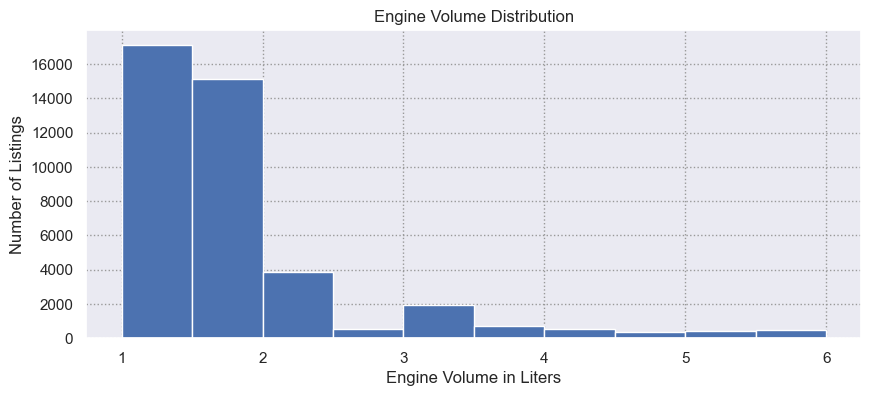

In [13]:
plt.figure(figsize=(10, 4))
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

data = df['engine_volume_l']
bins = np.arange(data.min(), data.max() + 1, 1)

plt.hist(df['engine_volume_l'])

plt.title("Engine Volume Distribution")
plt.xlabel("Engine Volume in Liters")
plt.ylabel("Number of Listings")

What I see
- Most posted cars has 1 to 2 liters capasity
- 3 or more engine capacity are rare  
  
What it might mean (interpretation)
- 1-2L engines dominate  because they are affordable, fuel-efficient cars directly aligned with Uzbekistan market where Chevrolet (Spark, and Cobalt) make up majority of sales.
- 1.5 - 2L engines being second most common in postings.
  
What I would next
- Check if engine valume corelates with. price
- Investigate 3+ valume engines seperately. IF they are truck or minibus, they can skew the data.
- Consider binning engine volume into 3 categories(`small` 0–1.6L, `mid` 1.6–2.5L, `large` 2.5L+) rather than using raw liters — it may be a stronger feature for a tree model

## Categorical Counts

### Brand, body type, transmission, fuel type (2×2 grid)

In [14]:
df.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,year_valid
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,NaN,...,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20,True
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00,True
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,NaN,...,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10,True
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,NaN,...,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05,True
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,626,626,Other,1250.0,NaN,NaN,NaN,16,1.60,True


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_6647/3757417397.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(fuel_type_counts.index, rotation=45, ha='right')


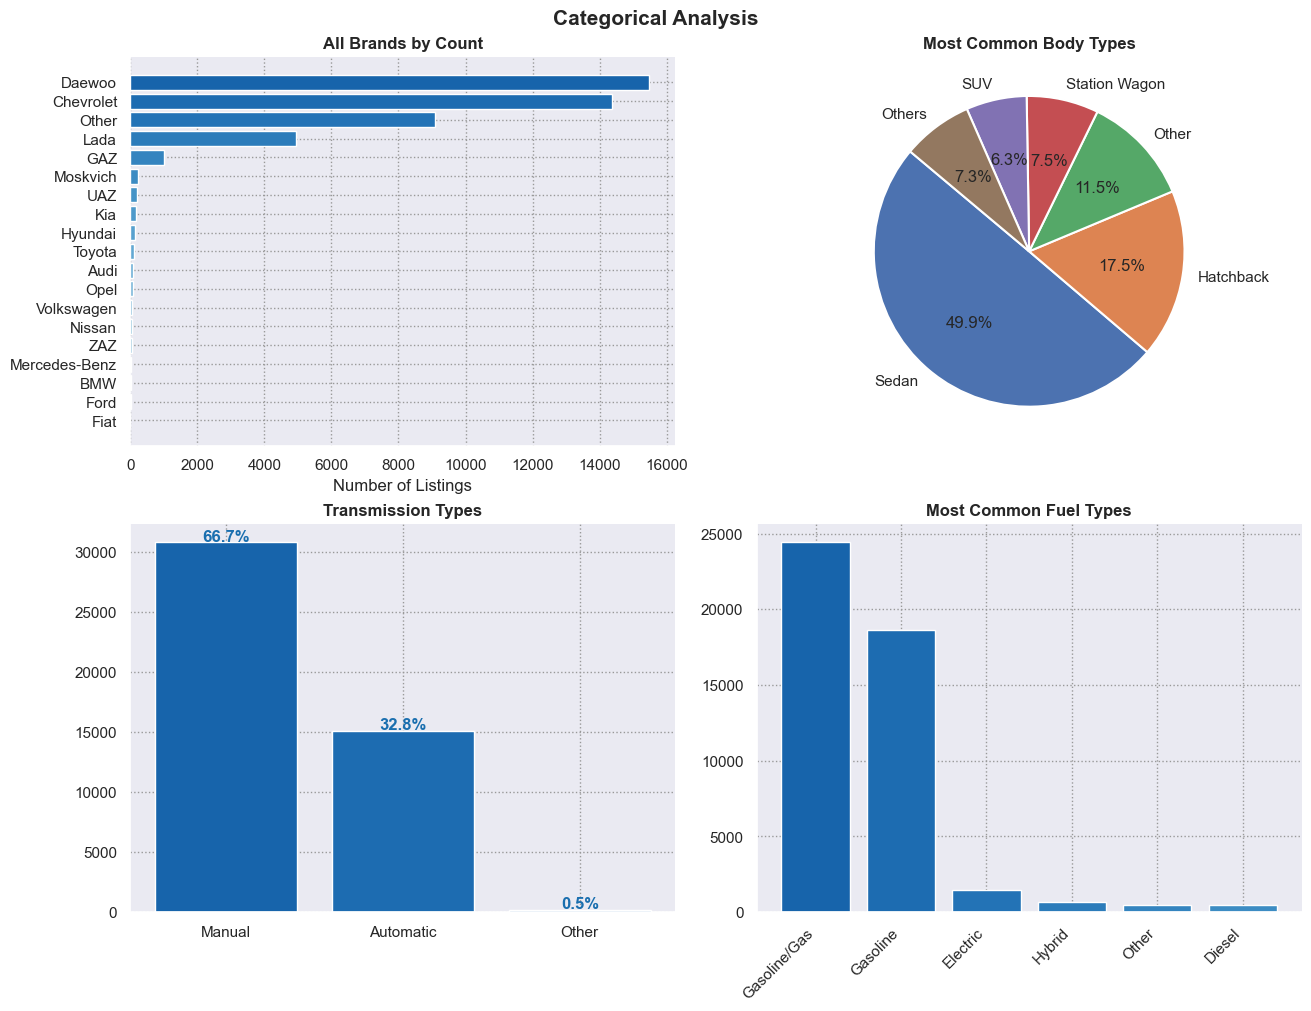

In [15]:
brand_counts = df['brand'].value_counts()

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(13, 10), layout="constrained")
fig.suptitle("Categorical Analysis", fontsize=15, fontweight='bold')

colors = plt.cm.Blues_r(np.linspace(0.2, 0.75, len(brand_counts)))


ax1 = axs[0, 0]
ax1.barh(brand_counts.index[::-1], brand_counts.values[::-1], color=colors[::-1])
ax1.set_title('All Brands by Count', fontweight='bold')
ax1.set_xlabel('Number of Listings')
ax1.spines[['top','right']].set_visible(False)

body_type_counts = df['body_type'].value_counts()
ax2 = axs[0, 1]
top5 = body_type_counts.head(5)
rest = body_type_counts.iloc[5:].sum()
pie_data = list(top5.values) + [rest]
pie_labels = list(top5.index) + ['Others']
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Most Common Body Types', fontweight='bold')

transmission_counts = df['transmission'].value_counts()
top = transmission_counts
ax3 = axs[1, 0]
pcts = top / transmission_counts.sum() * 100
bars = ax3.bar(top.index, top.values, color=colors[:5])
for bar, pct in zip(bars, pcts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{pct:.1f}%', ha='center', fontweight='bold', color='#1a6faf')
ax3.set_title('Transmission Types', fontweight='bold')
ax3.spines[['top','right']].set_visible(False)

ax4 = axs[1, 1]
fuel_type_counts = df['fuel_type'].value_counts()
ax4.bar(fuel_type_counts.index, fuel_type_counts.values, color=colors)
ax4.set_xticklabels(fuel_type_counts.index, rotation=45, ha='right')
ax4.set_title('Most Common Fuel Types', fontweight='bold')
ax4.spines[['top','right']].set_visible(False)

plt.show()

```markdown
What I see
- Each Daewoo and Chevrolet are holding more than 14000 postings
- Almost 50% of the cars has sedan type body
- Manual cars are 66.7 precent, While Automstic ones are less than 33%
- Cars that runs on both Gasoline and Gas are less that 25000 followed by cars that only runs on Gasoline closer to 17000
What it might mean (interpretation)
- The Market is heavily local and budget-orianted 
- All charts suggest affortable cars are being sold. 
What I would next
- In most common body types chart, there is a mistake, two `other` found 
- In transmission types chart, There is 0.5 precent but we dont exacly know what it is.
- Better short-term idea:
-  - Focus on gas-related services or used car analytics tools
- Long-term:
-  - Track EV growth over time (trend analysis) before investing
```

## Bivariate EDA

<function matplotlib.pyplot.show(close=None, block=None)>

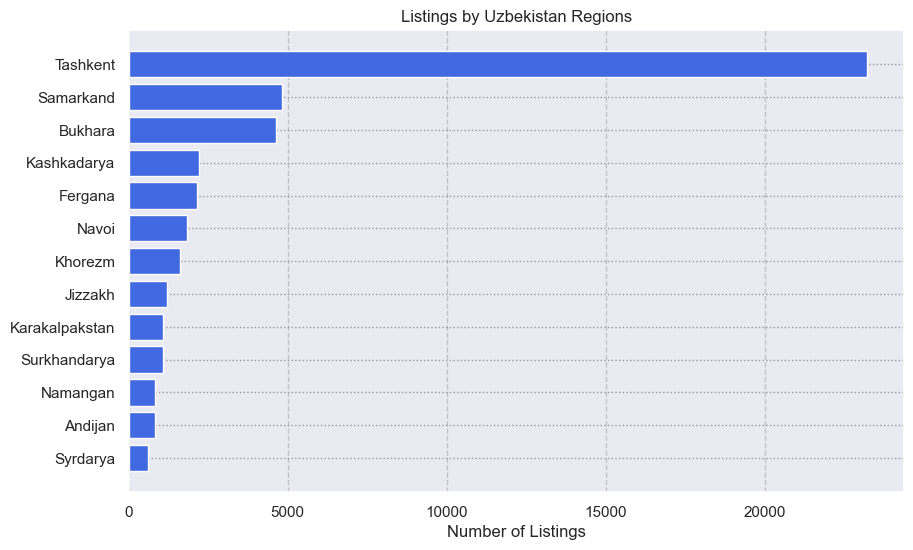

In [16]:
region_counts = df['region'].value_counts(ascending=True)
plt.figure(figsize=(10,6))
plt.barh(region_counts.index, region_counts.values,color="royalblue")
plt.title("Listings by Uzbekistan Regions")
plt.xlabel('Number of Listings')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show

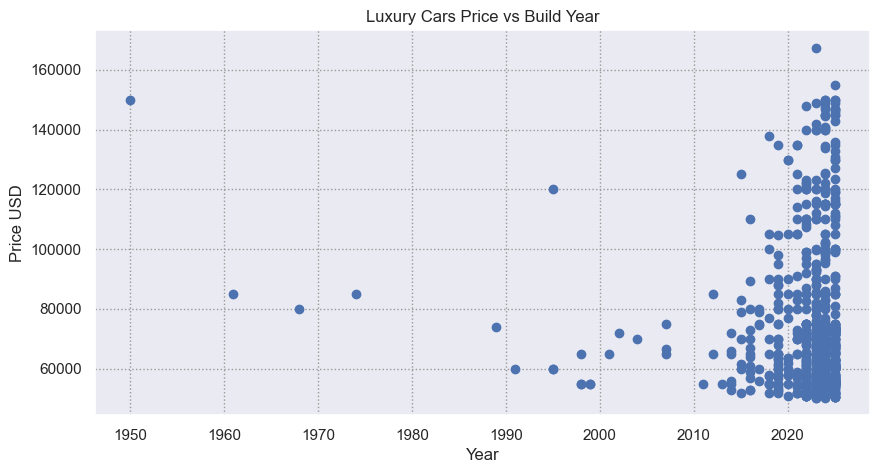

In [20]:
luxury_cars = df[df['price_usd'] > 50000]
regular_cars = df[df['price_usd'] <= 50000]

mask = luxury_cars['year_valid'] == True

plt.scatter(luxury_cars.loc[mask, 'year'],luxury_cars.loc[mask, 'price_usd'])
plt.title('Luxury Cars Price vs Build Year')
plt.ylabel('Price USD')
plt.xlabel('Year')
plt.show()

Text(0, 0.5, 'Price USD')

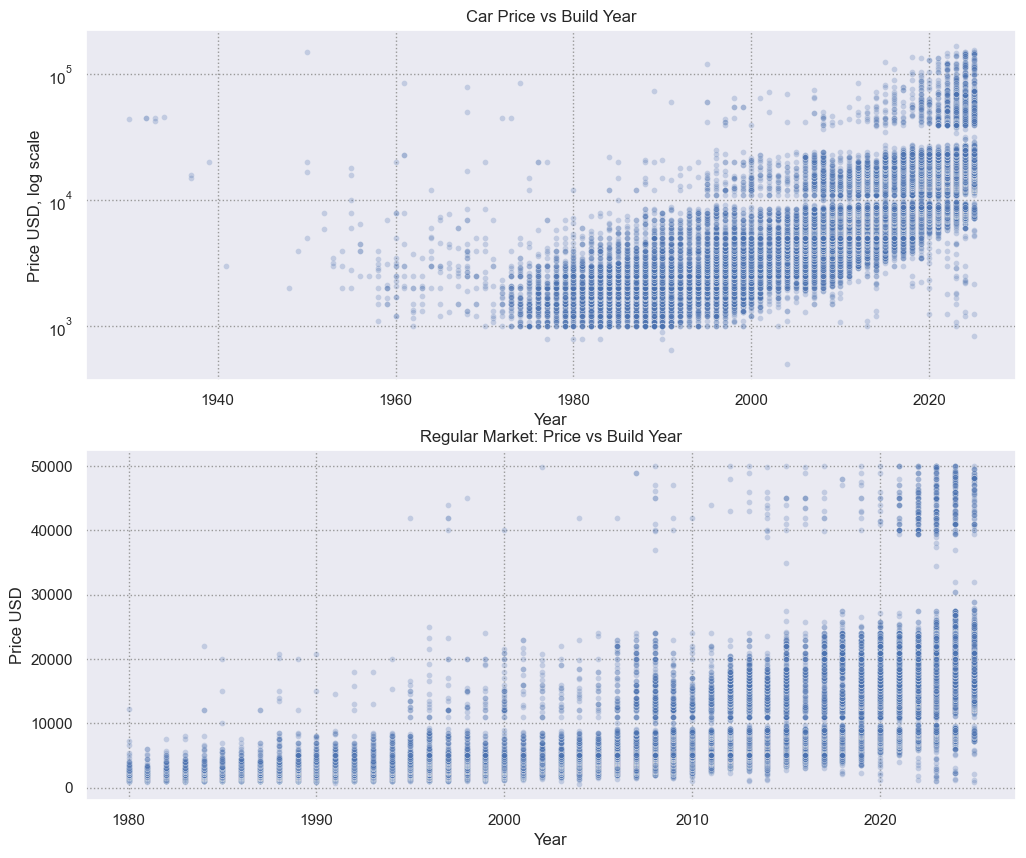

In [48]:
plot_df = df[
    df['year_valid'].eq(True)
    & df['price_usd'].notna()
    & df['year'].notna()
].copy()

plt.figure(figsize=(12,10))
plt.subplot(2,1,1)
sns.scatterplot(data=plot_df,x='year',y='price_usd',alpha=0.25,s=18)
plt.yscale('log')
plt.title('Car Price vs Build Year')
plt.xlabel('Year')
plt.ylabel('Price USD, log scale')

plt.subplot(2,1,2)
normal_df = plot_df[plot_df['price_usd'].between(500, 50000) & plot_df['year'].between(1980, 2026)
]
sns.scatterplot(data=normal_df, x='year', y='price_usd', alpha=0.25, s=18)
plt.title('Regular Market: Price vs Build Year')
plt.xlabel('Year')
plt.ylabel('Price USD')